#Content-Based Movie Reccomadation System Using NLP

This project implements a content-based movie recommendation system using Natural Language Processing (NLP) techniques and machine learning algorithms.

The recommendation engine suggests similar movies based on metadata features such as genres, keywords, cast, crew, and movie overview.

In [127]:
#importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import pickle
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [128]:
# Loading TMDB movie datasets using pandas
movies=pd.read_csv(
    "tmdb_5000_movies.csv"
)
credits = pd.read_csv(
    "tmdb_5000_credits.csv"
)

#Dateset Overview 

Understanding the structure and dimensions of the datasets before preprocessing.

In [129]:
movies.shape

(4803, 20)

In [130]:
credits.shape

(4803, 4)

In [131]:
# Merging movie and credits datasets
movies=movies.merge(credits,on='title')


## Select Important Features

Selecting only important metadata columns required for recommendation generation.

In [132]:

movies = movies[
    [
        'movie_id',
        'title',
        'overview',
        'genres',
        'keywords',
        'cast',
        'crew'
    ]
].copy()


In [133]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4809 non-null   int64 
 1   title     4809 non-null   object
 2   overview  4806 non-null   object
 3   genres    4809 non-null   object
 4   keywords  4809 non-null   object
 5   cast      4809 non-null   object
 6   crew      4809 non-null   object
dtypes: int64(1), object(6)
memory usage: 263.1+ KB


In [134]:
#overview has 3 missing values
#generes format

In [135]:
movies

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...,...,...,...
4804,9367,El Mariachi,El Mariachi just wants to play his guitar and ...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 5616, ""name"": ""united states\u2013mexi...","[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4805,72766,Newlyweds,A newlywed couple's honeymoon is upended by th...,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",[],"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4806,231617,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...","[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...","[{""id"": 248, ""name"": ""date""}, {""id"": 699, ""nam...","[{""cast_id"": 8, ""character"": ""Oliver O\u2019To...","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4807,126186,Shanghai Calling,When ambitious New York attorney Sam is sent t...,[],[],"[{""cast_id"": 3, ""character"": ""Sam"", ""credit_id...","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


## Data Preprocessing

Handling missing values and preparing the dataset for feature extraction.

In [136]:
movies=movies.dropna()

In [137]:
#rechecking for drop of null 

In [138]:
movies.shape

(4806, 7)

In [139]:
movies['genres'][0]

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

#Extracting:
- genres
- keywords
- top cast members
- director name


In [140]:
def extract_genres(obj):

    genres_list = []

    for i in ast.literal_eval(obj):

        genres_list.append(i['name'])

    return genres_list

In [141]:
def extract_keywords(obj):

    keywords_list = []

    for i in ast.literal_eval(obj):

        keywords_list.append(i['name'])

    return keywords_list

In [142]:
def extract_top_cast(obj):

    cast_list = []

    counter = 0

    for i in ast.literal_eval(obj):

        if counter != 3:

            cast_list.append(i['name'])

            counter += 1

        else:
            break

    return cast_list

In [143]:
def extract_director(obj):

    director_list = []

    for i in ast.literal_eval(obj):

        if i['job'] == 'Director':

            director_list.append(i['name'])

            break

    return director_list

##Apply Feature Extraction

Applying extraction functions to metadata columns.

In [144]:
movies.loc[:, 'genres'] = movies[
    'genres'
].apply(extract_genres)

movies.loc[:, 'keywords'] = movies[
    'keywords'
].apply(extract_keywords)

movies.loc[:, 'cast'] = movies[
    'cast'
].apply(extract_top_cast)

movies.loc[:, 'crew'] = movies[
    'crew'
].apply(extract_director)

In [145]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


## Exploratory Data Analysis

Analyzing movie genres and actor distribution in the dataset.

In [146]:
genres_counter = Counter()

for genres in movies['genres']:

    genres_counter.update(genres)

top_genres = pd.DataFrame(
    genres_counter.most_common(10),
    columns=['Genre', 'Count']
)

top_genres

,Genre,Count
0,Drama,2299
1,Comedy,1723
2,Thriller,1275
3,Action,1156
4,Romance,895
5,Adventure,792
6,Crime,697
7,Science Fiction,538
8,Horror,520
9,Family,514


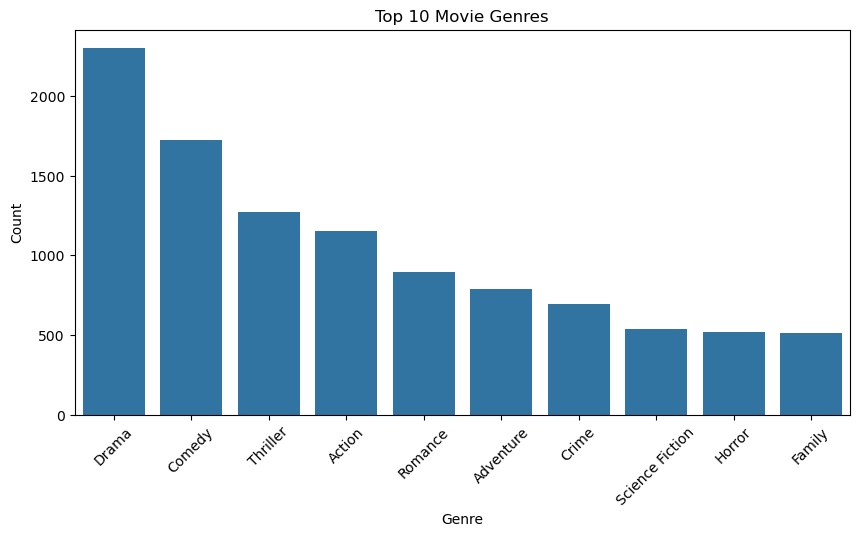

In [147]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_genres['Genre'],
    y=top_genres['Count']
)

plt.xticks(rotation=45)

plt.title("Top 10 Movie Genres")

plt.show()

## Text Preprocessing

Splitting overview text and removing spaces from metadata values for better NLP processing.

In [148]:
movies.loc[:, 'overview'] = movies[
    'overview'
].apply(lambda x: x.split())

In [149]:
movies.loc[:, 'genres'] = movies[
    'genres'
].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies.loc[:, 'keywords'] = movies[
    'keywords'
].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies.loc[:, 'cast'] = movies[
    'cast'
].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies.loc[:, 'crew'] = movies[
    'crew'
].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

In [150]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]


In [151]:
movies.loc[:, 'tags'] = (
    movies['genres'] +
    movies['keywords'] +
    movies['cast'] +
    movies['crew'] +
    movies['overview']
)

In [152]:
new_df = movies[
    [
        'movie_id',
        'title',
        'tags'
    ]
].copy()

In [153]:
new_df

,movie_id,title,tags
0,19995,Avatar,"[Action, Adventure, Fantasy, ScienceFiction, c..."
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action, ocean, drugabuse,..."
2,206647,Spectre,"[Action, Adventure, Crime, spy, basedonnovel, ..."
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller, dccomics, cri..."
4,49529,John Carter,"[Action, Adventure, ScienceFiction, basedonnov..."
...,...,...,...
4804,9367,El Mariachi,"[Action, Crime, Thriller, unitedstates–mexicob..."
4805,72766,Newlyweds,"[Comedy, Romance, EdwardBurns, KerryBishé, Mar..."
4806,231617,"Signed, Sealed, Delivered","[Comedy, Drama, Romance, TVMovie, date, loveat..."
4807,126186,Shanghai Calling,"[DanielHenney, ElizaCoupe, BillPaxton, DanielH..."


In [154]:
new_df.loc[:, 'tags'] = new_df[
    'tags'
].apply(
    lambda x: " ".join(x)
)

In [155]:
new_df

,movie_id,title,tags
0,19995,Avatar,Action Adventure Fantasy ScienceFiction cultur...
1,285,Pirates of the Caribbean: At World's End,Adventure Fantasy Action ocean drugabuse exoti...
2,206647,Spectre,Action Adventure Crime spy basedonnovel secret...
3,49026,The Dark Knight Rises,Action Crime Drama Thriller dccomics crimefigh...
4,49529,John Carter,Action Adventure ScienceFiction basedonnovel m...
...,...,...,...
4804,9367,El Mariachi,Action Crime Thriller unitedstates–mexicobarri...
4805,72766,Newlyweds,Comedy Romance EdwardBurns KerryBishé MarshaDi...
4806,231617,"Signed, Sealed, Delivered",Comedy Drama Romance TVMovie date loveatfirsts...
4807,126186,Shanghai Calling,DanielHenney ElizaCoupe BillPaxton DanielHsia ...


## Stemming

Applying stemming to reduce words to their root form and improve similarity matching.

In [156]:
import nltk
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

def stem(text):
    y=[]
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

new_df.loc[:, 'tags'] = new_df[
    'tags'
].apply(stem)

In [157]:
new_df.loc[:, 'tags'] = new_df[
    'tags'
].apply(
    lambda x: x.lower()
)

In [158]:
#now we have to find similarity b/w tags for recommandation -> vectorization
#text-> vector :BAG OF WORD


In [159]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=5000,stop_words='english')
x=cv.fit_transform(new_df['tags'])
vectors=x.toarray()

In [160]:
vectors.shape

(4806, 5000)

In [161]:

#vectors wrods me similar words h jaseke actor acotrs but ye sam ehine chaiye -> steaming nltk librarya


In [162]:
#from similarity b/w vectors cosine distance
#theta

In [163]:
from sklearn.metrics.pairwise import cosine_similarity
similarity=cosine_similarity(vectors)
sorted(list(enumerate(similarity[0])),reverse=True,key=lambda x:x[1])[1:6]

[(1214, np.float64(0.28676966733820225)),
 (2405, np.float64(0.26901379342448517)),
 (3728, np.float64(0.2605130246476754)),
 (507, np.float64(0.255608593705383)),
 (539, np.float64(0.2503866978335957))]

In [164]:
similarity[0]

array([1.        , 0.08346223, 0.0860309 , ..., 0.04499213, 0.        ,
       0.        ])

## Recommendation Function

Creating a recommendation function to return the most similar movies.

In [165]:
def recommend(movie):
    movie_index=new_df[new_df['title']==movie].index[0]
    distance=similarity[movie_index]
    movies_list=sorted(list(enumerate(distance)),reverse=True,key=lambda x:x[1])[1:6]
    for i in movies_list:
        print(new_df.iloc[i[0]].title)
        

## Test Recommendation System

Testing the recommendation engine using a sample movie.

In [166]:
recommend('Batman Begins')

The Dark Knight
Batman
Batman
The Dark Knight Rises
10th & Wolf


## Save Model

Saving processed movie data and similarity matrix using pickle for deployment.

In [167]:
import pickle
pickle.dump(new_df.to_dict(),open('movie-dict.pkl','wb'))

In [168]:
pickle.dump(similarity,open('similarity.pkl','wb'))